In [17]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [18]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from src.config import DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME

sns.set_style("whitegrid")

def get_engine():
    return create_engine(
        f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )

engine = get_engine()

# Load processed data (IMPORTANT: not raw)
df = pd.read_sql("SELECT * FROM transactions_processed", engine)

print(df.shape)
df.head()

(1048575, 13)


,step,type,amount,oldbalanceorg,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,orig_balance_error,dest_balance_error,is_orig_empty,is_dest_empty
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,9839.64,0,1
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,0.0,1864.28,0,1
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,0.0,181.00,0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,0.0,21363.00,0,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.0,11668.14,0,1


isfraud
0    1047433
1       1142
Name: count, dtype: int64


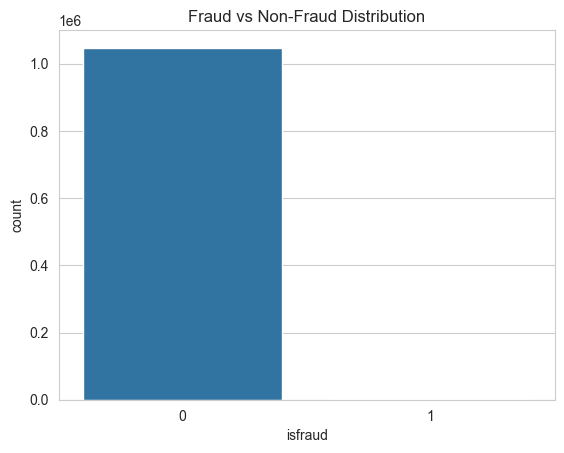

In [19]:
fraud_counts = df["isfraud"].value_counts()

print(fraud_counts)

sns.countplot(x="isfraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

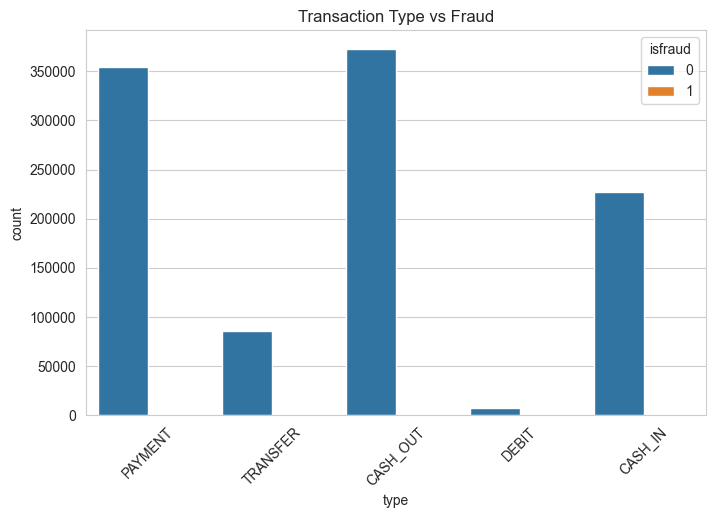

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="type", hue="isfraud", data=df)
plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=45)
plt.show()

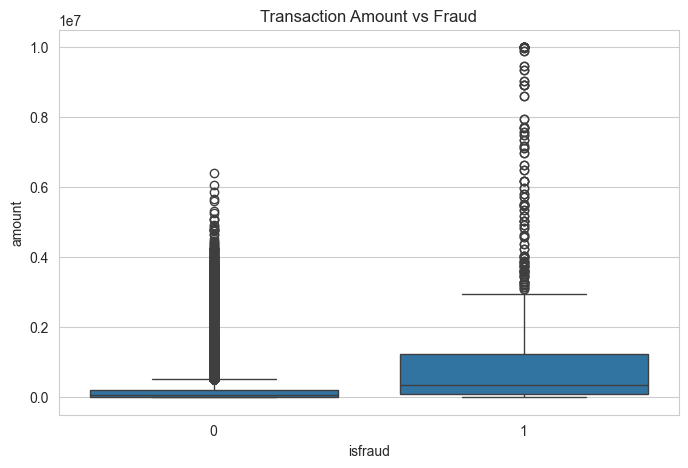

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="isfraud", y="amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

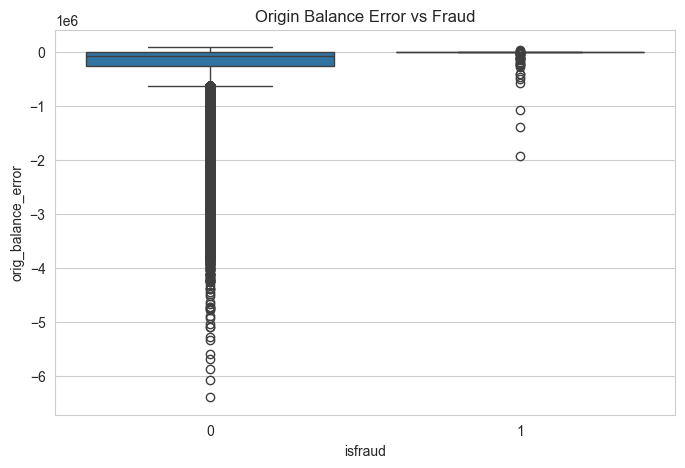

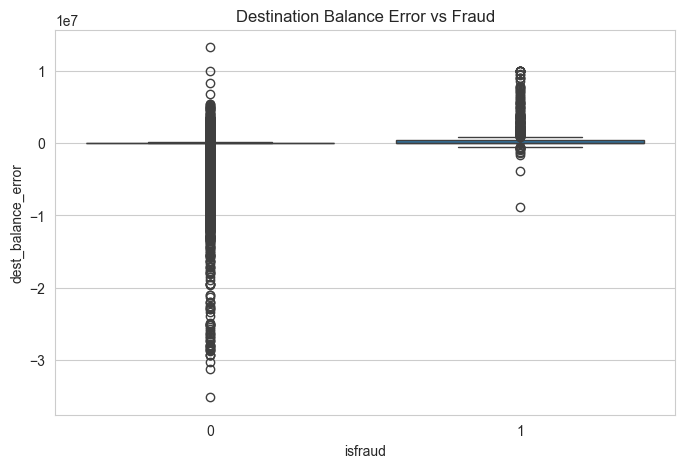

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="isfraud", y="orig_balance_error", data=df)
plt.title("Origin Balance Error vs Fraud")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="isfraud", y="dest_balance_error", data=df)
plt.title("Destination Balance Error vs Fraud")
plt.show()

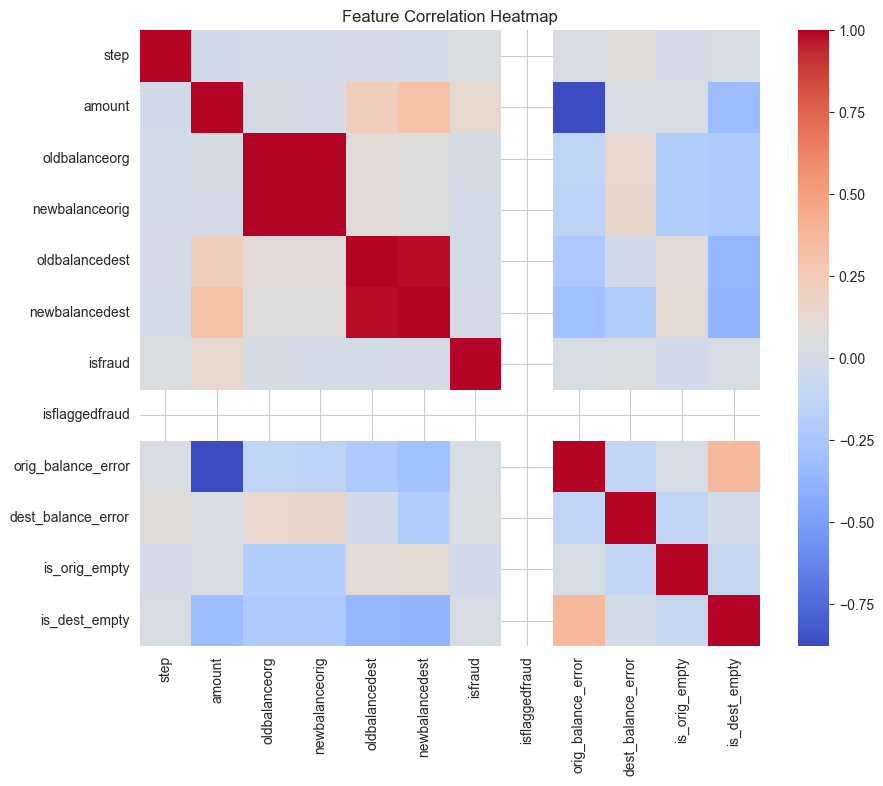

In [23]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

isfraud
0    0.998911
1    0.001089
Name: proportion, dtype: float64


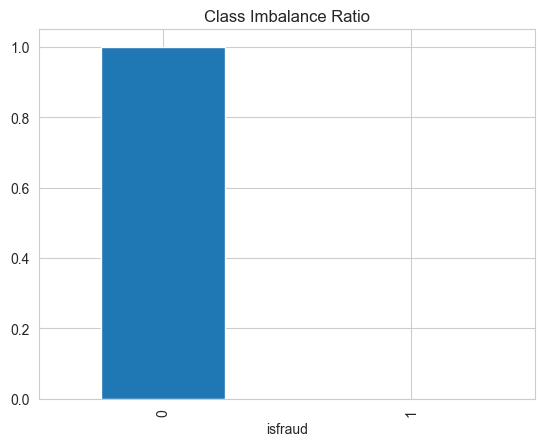

In [24]:
fraud_ratio = df["isfraud"].value_counts(normalize=True)

print(fraud_ratio)

fraud_ratio.plot(kind="bar")
plt.title("Class Imbalance Ratio")
plt.show()